In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from sklearn.inspection import permutation_importance

In [4]:


# ================================================================
# [2] Setup Paths and Output Directories
# ================================================================
os.makedirs('models/svm', exist_ok=True)
os.makedirs('models/svm/diagnostics', exist_ok=True)

print("="*80)
print("SVM MODEL - EARTHQUAKE CATALOG Declustering")
print("="*80)

# ================================================================
# [3] Load Synthetic and Real Catalog Data
# ================================================================
print("\n[1] Loading Data...")

synthetic_path = '/home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_synthetic_catalog.csv'
real_path = '/home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_real_catalog.csv'

synthetic_data = pd.read_csv(synthetic_path)
real_data = pd.read_csv(real_path)

print(f"Synthetic data shape: {synthetic_data.shape}")
print(f"Real data shape: {real_data.shape}")

SVM MODEL - EARTHQUAKE CATALOG Declustering

[1] Loading Data...
Synthetic data shape: (100503, 20)
Real data shape: (396267, 22)


In [5]:
synthetic_data.head()

,event,DateTime,Date,Year,Month,Day,time,latitude,longitude,magnitude,Generation,ParentID,Label,i+,N+,T+,R+,dm+,n_child,n_parent
0,8,2005-01-01 01:10:00.825848852,2005-01-01,2005,1,1,0.048621,-37.396225,177.987203,3.301688,0,NaN,background,0,2.097547e-04,0.000694,3.021055e-01,0.176485,0.036315,0.036315
1,41,2005-01-01 05:42:37.953139645,2005-01-01,2005,1,1,0.237939,-37.124231,177.535453,3.163747,1,1754.0,triggered,1,2.702490e-05,0.003774,7.160450e-03,0.137941,0.036315,0.036315
2,46,2005-01-01 05:43:05.509842873,2005-01-01,2005,1,1,0.238258,-37.123676,177.537697,3.500583,1,1754.0,triggered,2,1.064500e-11,0.000007,1.421550e-06,-0.336836,0.072630,0.036315
3,47,2005-01-01 05:43:17.946950013,2005-01-01,2005,1,1,0.238402,-42.631090,167.284364,3.736844,0,NaN,background,3,1.811590e-06,0.000002,7.991986e-01,-0.236261,0.000000,0.072630
4,48,2005-01-01 05:43:23.387341987,2005-01-01,2005,1,1,0.238465,-37.123590,177.536278,3.048787,1,1754.0,triggered,3,1.428314e-12,0.000003,4.383602e-07,0.451797,0.036315,0.072630


In [6]:
real_data.head()

,event,date,Time,latitude,longitude,depth,magnitude,DateTime,time,Year,...,Hour,Minute,Second,i+,N+,T+,R+,dm+,n_child,n_parent
0,2,1980-01-01,09:27:04.52,-40.490,174.66901,72.6,3.200,1980-01-01 09:27:04.520,0.099293,1980,...,9,27,4.52,0,0.000217,0.004731,0.045941,-0.633,0.082958,0.041479
1,3,1980-01-01,18:28:10.99,-37.630,176.38000,210.0,4.150,1980-01-01 18:28:10.990,0.475062,1980,...,18,28,10.99,1,0.001304,0.008451,0.154341,-0.950,0.124437,0.082958
2,4,1980-01-01,20:20:54.03,-40.290,173.42999,212.0,4.500,1980-01-01 20:20:54.030,0.553338,1980,...,20,20,54.03,2,0.000038,0.000571,0.066251,-0.350,0.165915,0.124437
3,5,1980-01-02,18:24:15.40,-38.480,176.75000,5.0,3.375,1980-01-02 18:24:15.400,1.472336,1980,...,18,24,15.40,2,0.000047,0.007270,0.006458,0.775,0.000000,0.124437
4,6,1980-01-04,01:21:41.06,-40.906,175.23700,24.1,2.750,1980-01-04 01:21:41.060,2.762216,1980,...,1,21,41.06,3,0.000144,0.010633,0.013547,1.750,0.041479,0.165915


## Correlation Matrix


[2] Correlation Analysis...

--- Synthetic Catalog Correlation Matrix ---
               event   Year  Month    Day   time  latitude  longitude  \
event          1.000  0.995  0.100  0.014  1.000    -0.005      0.002   
Year           0.995  1.000  0.001  0.005  0.995    -0.003      0.001   
Month          0.100  0.001  1.000  0.014  0.100    -0.015      0.004   
Day            0.014  0.005  0.014  1.000  0.015    -0.002     -0.001   
time           1.000  0.995  0.100  0.015  1.000    -0.005      0.002   
latitude      -0.005 -0.003 -0.015 -0.002 -0.005     1.000     -0.007   
longitude      0.002  0.001  0.004 -0.001  0.002    -0.007      1.000   
magnitude      0.002  0.002 -0.004 -0.005  0.002     0.003      0.002   
Generation    -0.009 -0.009  0.001  0.000 -0.009    -0.000      0.004   
ParentID       0.012  0.011  0.015  0.004  0.012     0.008     -0.003   
i+             0.965  0.961  0.090  0.014  0.965     0.020     -0.011   
N+            -0.036 -0.038  0.014  0.003 -0.036 

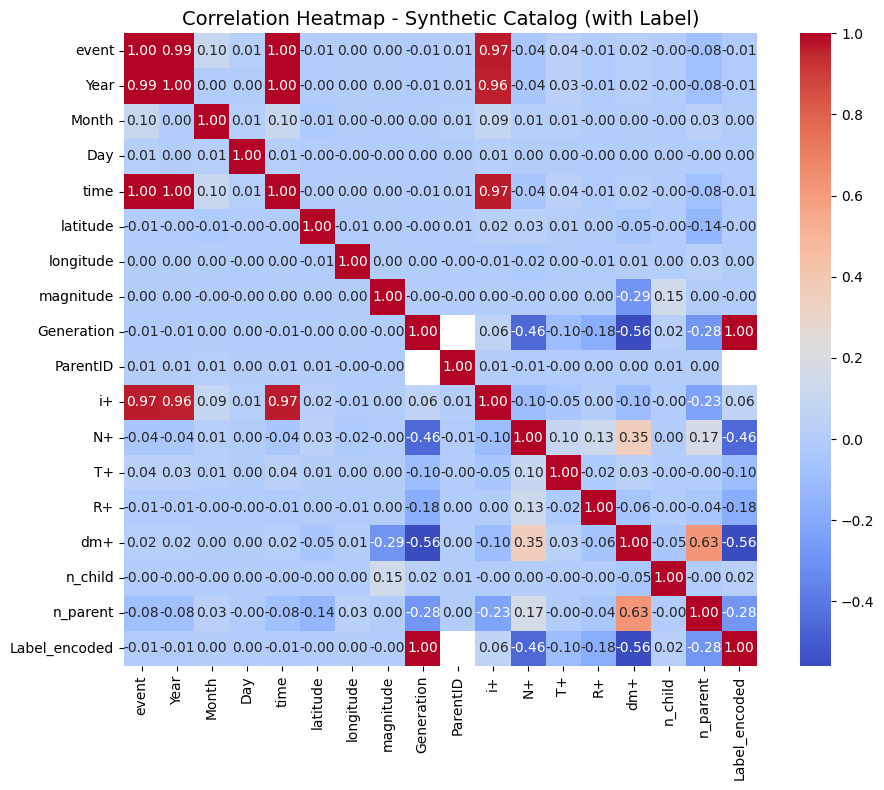

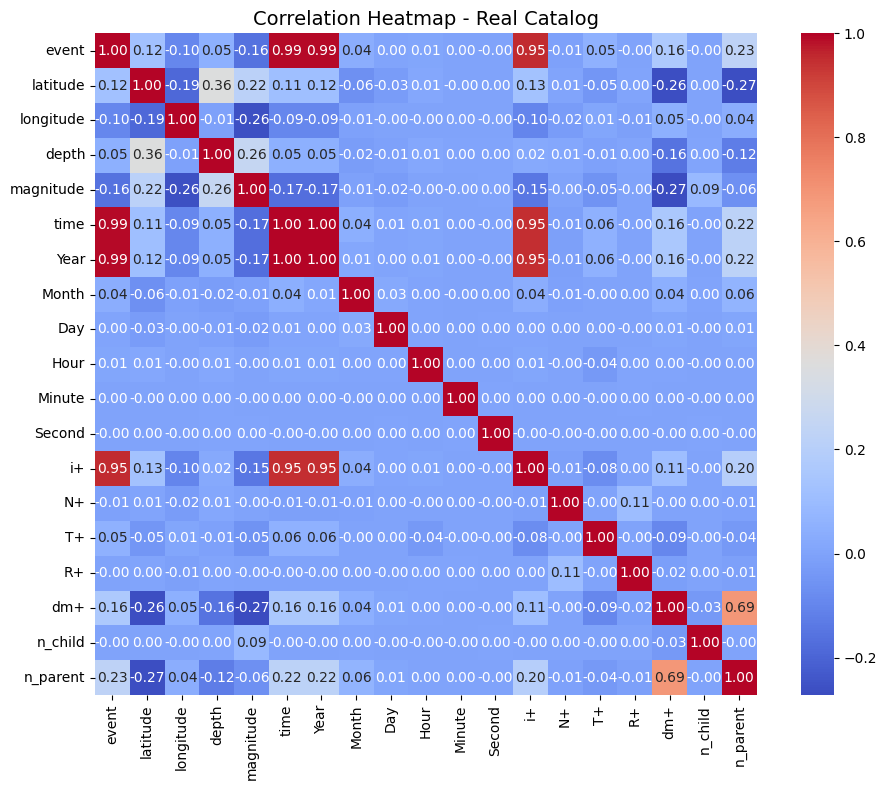

In [7]:
print("\n[2] Correlation Analysis...")

# Encode Label column if it exists
if 'Label' in synthetic_data.columns:
    synthetic_data['Label_encoded'] = synthetic_data['Label'].replace({'background': 0, 'triggered': 1})
if 'Label' in real_data.columns:
    real_data['Label_encoded'] = real_data['Label'].replace({'background': 0, 'triggered': 1})

# Select only numeric columns
synthetic_corr = synthetic_data.select_dtypes(include=['float64', 'int64']).corr()
real_corr = real_data.select_dtypes(include=['float64', 'int64']).corr()

# Print correlation matrices
print("\n--- Synthetic Catalog Correlation Matrix ---")
print(synthetic_corr.round(3))

print("\n--- Real Catalog Correlation Matrix ---")
print(real_corr.round(3))

# ================================================================
# Visualize Correlation Heatmaps
# ================================================================
plt.figure(figsize=(10, 8))
sns.heatmap(synthetic_corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Heatmap - Synthetic Catalog (with Label)", fontsize=14)
plt.tight_layout()
plt.savefig('models/svm/synthetic_catalog_correlation_heatmap.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(real_corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Heatmap - Real Catalog", fontsize=14)
plt.tight_layout()
plt.savefig('models/svm/real_catalog_correlation_heatmap.png', dpi=300)
plt.show()


In [8]:
# ================================================================
# [4] Feature Preparation and Label Encoding
# ================================================================
print("\n[2] Preparing Features and Labels...")

features = [ 'N+', 'T+', 'R+', 'dm+', 'n_child', 'n_parent']

# Drop missing values
synthetic_data = synthetic_data.dropna(subset=features + ['Label'])
real_data = real_data.dropna(subset=features)

X = synthetic_data[features]
y = synthetic_data['Label']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print("Encoded labels:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

# ================================================================
# [5] Data Scaling (Important for SVM)
# ================================================================
print("\n[3] Scaling Features...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
real_scaled = scaler.transform(real_data[features])

# ================================================================
# [6] Train-Test Split
# ================================================================
print("\n[4] Splitting Data into Train & Validation...")

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42
)
print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")



[2] Preparing Features and Labels...
Encoded labels: {'background': 0, 'triggered': 1}

[3] Scaling Features...

[4] Splitting Data into Train & Validation...
Training samples: 70352, Validation samples: 30151


In [10]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import numpy as np
import os
import matplotlib.pyplot as plt


In [12]:
# ================================================================
# [7] Model Training (SVM with RBF Kernel)
# ================================================================
print("\n[5] Training SVM Model...")

model = SVC(
    kernel='rbf',
    C=2.0,
    gamma='scale',
    probability=True,
    random_state=42
)
model.fit(X_train, y_train)

# ================================================================
# [8] Evaluate on Validation Set
# ================================================================
print("\n[6] Evaluating Model on Validation Data...")

y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1] if len(np.unique(y_val)) == 2 else None

# Basic metrics
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='weighted')
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

# ROC–AUC
if y_pred_proba is not None:
    roc_auc = roc_auc_score(y_val, y_pred_proba)
else:
    roc_auc = roc_auc_score(y_val, model.decision_function(X_val), multi_class='ovr', average='weighted')

# Specificity (for binary)
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
else:
    specificity = None

# ================================================================
# Print All Metrics
# ================================================================
print("\n=== MODEL PERFORMANCE SUMMARY ===")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC–AUC      : {roc_auc:.4f}")
if specificity is not None:
    print(f"Specificity  : {specificity:.4f}")

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_val, y_pred, target_names=encoder.classes_))

# ================================================================
# Save Model Summary
# ================================================================
os.makedirs('models/svm', exist_ok=True)

with open('models/svm/model_summary.txt', 'w') as f:
    f.write("SVM Model Summary\n")
    f.write("="*60 + "\n")
    f.write(f"Accuracy     : {acc:.4f}\n")
    f.write(f"Precision    : {precision:.4f}\n")
    f.write(f"Recall       : {recall:.4f}\n")
    f.write(f"F1 Score     : {f1:.4f}\n")
    f.write(f"ROC–AUC      : {roc_auc:.4f}\n")
    if specificity is not None:
        f.write(f"Specificity  : {specificity:.4f}\n")
    f.write("\nConfusion Matrix:\n")
    f.write(np.array2string(cm))
    f.write("\n\nClassification Report:\n")
    f.write(classification_report(y_val, y_pred, target_names=encoder.classes_))

print("\n→ Model performance summary saved successfully.")



[5] Training SVM Model...

[6] Evaluating Model on Validation Data...

=== MODEL PERFORMANCE SUMMARY ===
Accuracy     : 0.9436
Precision    : 0.9448
Recall       : 0.9436
F1 Score     : 0.9440
ROC–AUC      : 0.9823
Specificity  : 0.9293

Confusion Matrix:
 [[ 8272   629]
 [ 1072 20178]]

Classification Report:
               precision    recall  f1-score   support

  background       0.89      0.93      0.91      8901
   triggered       0.97      0.95      0.96     21250

    accuracy                           0.94     30151
   macro avg       0.93      0.94      0.93     30151
weighted avg       0.94      0.94      0.94     30151


→ Model performance summary saved successfully.



[7] Plotting Confusion Matrix...


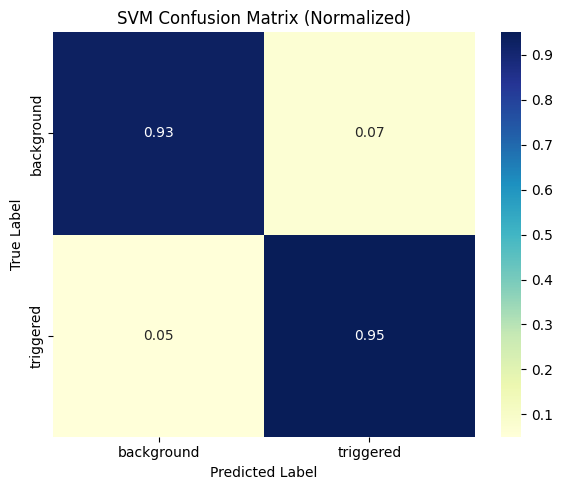


[8] Performing 5-Fold Cross-Validation...
CV Accuracy: [0.9406 0.9441 0.9454 0.9456 0.9475]
CV F1: [0.9574 0.9599 0.961  0.961  0.9625]
Mean CV Accuracy: 0.9446 ± 0.0023
Mean CV F1: 0.9603 ± 0.0017

[9] ROC-AUC Analysis...


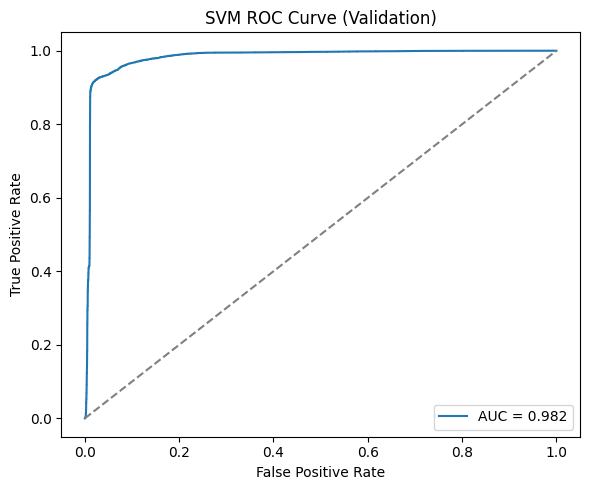

Validation ROC-AUC: 0.9823

[10] Computing Permutation Importance...


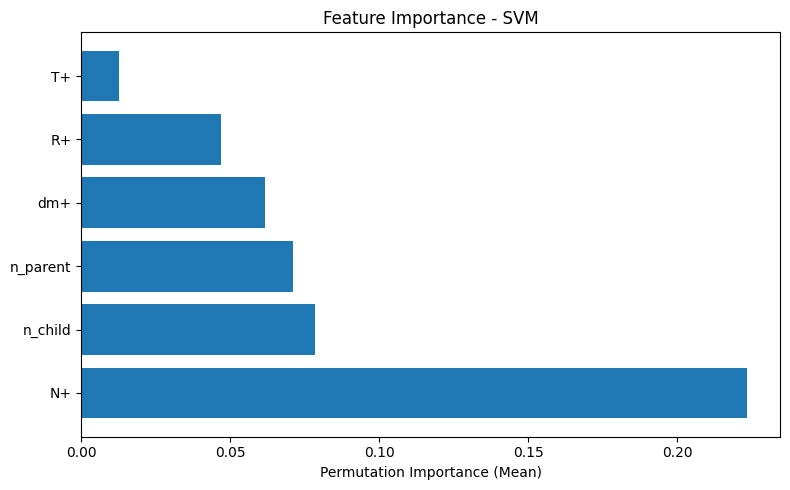

→ Feature importance plot saved to models/svm/feature_importance.png


In [13]:

# ================================================================
# [9] Confusion Matrix Visualization
# ================================================================
print("\n[7] Plotting Confusion Matrix...")

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("SVM Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('models/svm/confusion_matrix.png', dpi=300)
plt.show()

# ================================================================
# [10] Cross-Validation Diagnostics
# ================================================================
print("\n[8] Performing 5-Fold Cross-Validation...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(model, X_scaled, y_encoded, cv=skf, scoring='accuracy')
cv_f1 = cross_val_score(model, X_scaled, y_encoded, cv=skf, scoring='f1')

print("CV Accuracy:", np.round(cv_acc, 4))
print("CV F1:", np.round(cv_f1, 4))
print(f"Mean CV Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"Mean CV F1: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

with open('models/svm/diagnostics/cv_summary.txt', 'w') as f:
    f.write("SVM 5-Fold Cross-Validation Summary\n")
    f.write(f"Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}\n")
    f.write(f"F1: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}\n")

# ================================================================
# [11] ROC Curve (Validation)
# ================================================================
print("\n[9] ROC-AUC Analysis...")

y_prob = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_prob)
fpr, tpr, _ = roc_curve(y_val, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve (Validation)")
plt.legend()
plt.tight_layout()
plt.savefig('models/svm/roc_curve.png', dpi=300)
plt.show()
print(f"Validation ROC-AUC: {auc:.4f}")

# ================================================================
# [12] Permutation Feature Importance (Validation)
# ================================================================
print("\n[10] Computing Permutation Importance...")

perm = permutation_importance(model, X_val, y_val, n_repeats=20, random_state=42)
sorted_idx = perm.importances_mean.argsort()[::-1]

plt.figure(figsize=(8,5))
plt.barh(np.array(features)[sorted_idx], perm.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Mean)")
plt.title("Feature Importance - SVM")
plt.tight_layout()
plt.savefig('models/svm/feature_importance.png', dpi=300)
plt.show()

print("→ Feature importance plot saved to models/svm/feature_importance.png")


In [14]:
# ================================================================
# [13] Apply Model to Real Catalog
# ================================================================
print("\n[11] Predicting on Real Catalog...")

real_pred = model.predict(real_scaled)
real_pred_labels = encoder.inverse_transform(real_pred)

real_data['Predicted_Label'] = real_pred_labels
real_data.to_csv('models/svm/real_catalog_with_predictions.csv', index=False)
print("→ Real catalog predictions saved to models/svm/real_catalog_with_predictions.csv")

# ================================================================
# [14] Prediction Distribution
# ================================================================
print("\n[12] Prediction Distribution on Real Catalog:")

# Get both count and percent
pred_counts = real_data['Predicted_Label'].value_counts()
pred_percent = real_data['Predicted_Label'].value_counts(normalize=True) * 100

# Combine into a single table
pred_summary = pd.DataFrame({
    'Count': pred_counts,
    'Percent (%)': pred_percent.round(2)
})

# Print neatly
print(pred_summary)

# Optional: save this summary
pred_summary.to_csv('models/svm/prediction_distribution_summary.csv', index=True)
print("→ Prediction distribution summary saved to models/svm/prediction_distribution_summary.csv")

# ================================================================
# END
# ================================================================
print("\n✅ SVM model training, validation, and prediction completed successfully!")



[11] Predicting on Real Catalog...
→ Real catalog predictions saved to models/svm/real_catalog_with_predictions.csv

[12] Prediction Distribution on Real Catalog:
                  Count  Percent (%)
Predicted_Label                     
background       289241        72.99
triggered        107026        27.01
→ Prediction distribution summary saved to models/svm/prediction_distribution_summary.csv

✅ SVM model training, validation, and prediction completed successfully!
